In [66]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [67]:
year = 2024



In [68]:
url = f"https://api.census.gov/data/{year}/acs/acs5"

params = {
    "get": "NAME,B19013_001E,B25064_001E",
    "for": "county:*",
    "in": "state:36"
}

response = requests.get(url, params=params)
response.raise_for_status()

print("Status:", response.status_code)
print("Final URL:", response.url)
print("Content type:", response.headers.get("content-type"))
print(response.text[:1000])

Status: 200
Final URL: https://api.census.gov/data/missing_key.html
Content type: text/html
<html style="font-size: 14px;">

<head>
    <title>Missing Key</title>
    <link rel="icon" type="image/x-icon" href="favicon.ico">
    <link rel="stylesheet" type="text/css" href="assets/styles.css">
    <script type="text/javascript" src="assets/jquery-1.4.4.min.js"></script>
    <script type="text/javascript">
        $(document).ready(function () {
            function getCookie(name) {
                const value = `; ${document.cookie}`;
                const parts = value.split(`; ${name}=`);
                if (parts.length === 2) return parts.pop().split(';').shift();
                return null;
            }

            // Get the referrer from the cookie
            document.getElementById('text-field').value = decodeURIComponent(getCookie('originalReferer'));
            
            $(".menu-activator").click(function () {
                $(".gov-menu").toggle()
                $(

In [69]:
from google.colab import userdata

census_key = userdata.get("CENSUS_API_KEY")

In [70]:
url = f"https://api.census.gov/data/{year}/acs/acs5"

params = {
    "get": "NAME,B19013_001E,B25064_001E",
    "for": "county:*",
    "in": "state:36",
    "key": census_key
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

data[:3]

[['NAME', 'B19013_001E', 'B25064_001E', 'state', 'county'],
 ['Albany County, New York', '85333', '1313', '36', '001'],
 ['Allegany County, New York', '62869', '763', '36', '003']]

In [71]:
df = pd.DataFrame(data[1:], columns=data[0])

df.head()

,NAME,B19013_001E,B25064_001E,state,county
0,"Albany County, New York",85333,1313,36,001
1,"Allegany County, New York",62869,763,36,003
2,"Bronx County, New York",48676,1458,36,005
3,"Broome County, New York",62616,941,36,007
4,"Cattaraugus County, New York",59540,770,36,009


In [72]:
df = df.rename(columns={
    "NAME": "county_name",
    "B19013_001E": "median_household_income",
    "B25064_001E": "median_gross_rent"
})

df.head()

,county_name,median_household_income,median_gross_rent,state,county
0,"Albany County, New York",85333,1313,36,001
1,"Allegany County, New York",62869,763,36,003
2,"Bronx County, New York",48676,1458,36,005
3,"Broome County, New York",62616,941,36,007
4,"Cattaraugus County, New York",59540,770,36,009


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   county_name              62 non-null     object
 1   median_household_income  62 non-null     object
 2   median_gross_rent        62 non-null     object
 3   state                    62 non-null     object
 4   county                   62 non-null     object
dtypes: object(5)
memory usage: 2.6+ KB


In [74]:
df["median_household_income"] = pd.to_numeric(
    df["median_household_income"], errors="coerce"
)

df["median_gross_rent"] = pd.to_numeric(
    df["median_gross_rent"], errors="coerce"
)

df[["median_household_income", "median_gross_rent"]].dtypes

,0
median_household_income,int64
median_gross_rent,int64


In [75]:
df.isnull().sum()

,0
county_name,0
median_household_income,0
median_gross_rent,0
state,0
county,0


In [76]:
nyc_counties = [
    "Bronx County, New York",
    "Kings County, New York",
    "New York County, New York",
    "Queens County, New York",
    "Richmond County, New York"
]

nyc = df[df["county_name"].isin(nyc_counties)].copy()

nyc

,county_name,median_household_income,median_gross_rent,state,county
2,"Bronx County, New York",48676,1458,36,005
23,"Kings County, New York",80263,1833,36,047
30,"New York County, New York",103931,2197,36,061
40,"Queens County, New York",86136,1956,36,081
42,"Richmond County, New York",98333,1733,36,085


In [77]:
borough_names = {
    "Bronx County, New York": "Bronx",
    "Kings County, New York": "Brooklyn",
    "New York County, New York": "Manhattan",
    "Queens County, New York": "Queens",
    "Richmond County, New York": "Staten Island"
}

nyc["borough"] = nyc["county_name"].map(borough_names)

nyc[["borough", "median_household_income", "median_gross_rent"]]

,borough,median_household_income,median_gross_rent
2,Bronx,48676,1458
23,Brooklyn,80263,1833
30,Manhattan,103931,2197
40,Queens,86136,1956
42,Staten Island,98333,1733


In [78]:
nyc["annual_gross_rent"] = nyc["median_gross_rent"] * 12

In [79]:
nyc["rent_to_income_pct"] = (
    nyc["annual_gross_rent"] / nyc["median_household_income"] * 100
)

nyc[[
    "borough",
    "median_household_income",
    "median_gross_rent",
    "annual_gross_rent",
    "rent_to_income_pct"
]].sort_values("rent_to_income_pct", ascending=False)

,borough,median_household_income,median_gross_rent,annual_gross_rent,rent_to_income_pct
2,Bronx,48676,1458,17496,35.943792
23,Brooklyn,80263,1833,21996,27.404906
40,Queens,86136,1956,23472,27.249930
30,Manhattan,103931,2197,26364,25.366830
42,Staten Island,98333,1733,20796,21.148546


In [80]:
def get_census_data(year):
    url = f"https://api.census.gov/data/{year}/acs/acs5"

    params = {
        "get": "NAME,B19013_001E,B25064_001E",
        "for": "county:*",
        "in": "state:36",
        "key": census_key
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    yearly_df = pd.DataFrame(data[1:], columns=data[0])

    yearly_df = yearly_df.rename(columns={
        "NAME": "county_name",
        "B19013_001E": "median_household_income",
        "B25064_001E": "median_gross_rent"
    })

    yearly_df["median_household_income"] = pd.to_numeric(
        yearly_df["median_household_income"], errors="coerce"
    )

    yearly_df["median_gross_rent"] = pd.to_numeric(
        yearly_df["median_gross_rent"], errors="coerce"
    )

    yearly_df = yearly_df[
        yearly_df["county_name"].isin(nyc_counties)
    ].copy()

    yearly_df["borough"] = yearly_df["county_name"].map(borough_names)
    yearly_df["year"] = year

    yearly_df["annual_gross_rent"] = (
        yearly_df["median_gross_rent"] * 12
    )

    yearly_df["rent_to_income_pct"] = (
        yearly_df["annual_gross_rent"]
        / yearly_df["median_household_income"]
        * 100
    )

    return yearly_df

In [81]:
test_2023 = get_census_data(2023)

test_2023[[
    "borough",
    "year",
    "median_household_income",
    "median_gross_rent",
    "rent_to_income_pct"
]]

,borough,year,median_household_income,median_gross_rent,rent_to_income_pct
2,Bronx,2023,49036,1436,35.141529
23,Brooklyn,2023,78548,1784,27.254672
30,Manhattan,2023,104553,2132,24.469886
40,Queens,2023,84961,1915,27.047704
42,Staten Island,2023,98290,1689,20.620612


In [82]:
years = range(2015, 2025)

all_years = []

for year in years:
    yearly_data = get_census_data(year)
    all_years.append(yearly_data)

nyc_trends = pd.concat(all_years, ignore_index=True)

nyc_trends.shape

(50, 9)

In [83]:
nyc_trends.groupby("year")["borough"].count()

,borough
year,
2015,5
2016,5
2017,5
2018,5
2019,5
2020,5
2021,5
2022,5
2023,5


In [84]:
start = nyc_trends[nyc_trends["year"] == 2015][
    ["borough", "median_household_income", "median_gross_rent", "rent_to_income_pct"]
].copy()

end = nyc_trends[nyc_trends["year"] == 2024][
    ["borough", "median_household_income", "median_gross_rent", "rent_to_income_pct"]
].copy()

change = start.merge(end, on="borough", suffixes=("_2015", "_2024"))

change

,borough,median_household_income_2015,median_gross_rent_2015,rent_to_income_pct_2015,median_household_income_2024,median_gross_rent_2024,rent_to_income_pct_2024
0,Queens,57720,1367,28.419958,86136,1956,27.249930
1,Manhattan,72871,1519,25.014066,103931,2197,25.366830
2,Bronx,34299,1074,37.575440,48676,1458,35.943792
3,Brooklyn,48201,1215,30.248335,80263,1833,27.404906
4,Staten Island,73197,1169,19.164720,98333,1733,21.148546


In [85]:
change["income_change_pct"] = (
    (change["median_household_income_2024"] - change["median_household_income_2015"])
    / change["median_household_income_2015"] * 100
)

change["rent_change_pct"] = (
    (change["median_gross_rent_2024"] - change["median_gross_rent_2015"])
    / change["median_gross_rent_2015"] * 100
)

change["affordability_change"] = (
    change["rent_to_income_pct_2024"] - change["rent_to_income_pct_2015"]
)

change[[
    "borough",
    "income_change_pct",
    "rent_change_pct",
    "affordability_change"
]].round(2)

,borough,income_change_pct,rent_change_pct,affordability_change
0,Queens,49.23,43.09,-1.17
1,Manhattan,42.62,44.63,0.35
2,Bronx,41.92,35.75,-1.63
3,Brooklyn,66.52,50.86,-2.84
4,Staten Island,34.34,48.25,1.98


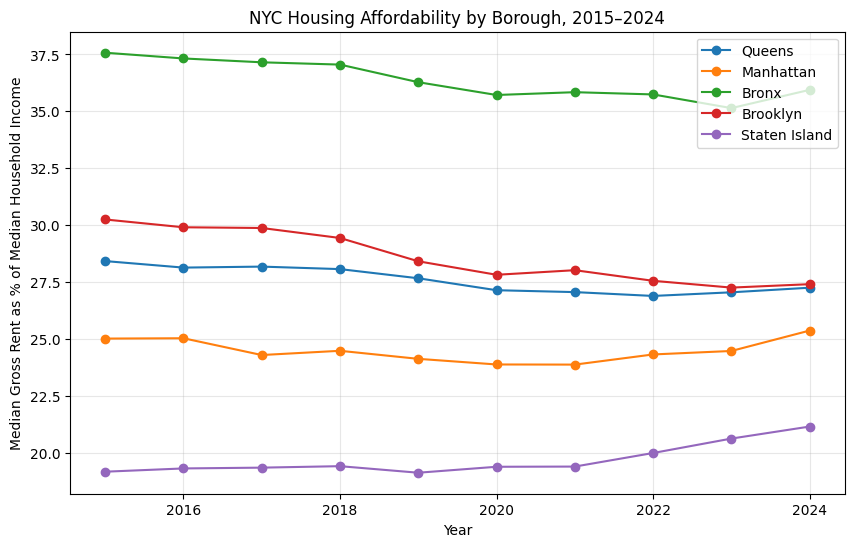

In [86]:
plt.figure(figsize=(10, 6))

for borough in nyc_trends["borough"].unique():
    borough_data = nyc_trends[nyc_trends["borough"] == borough]

    plt.plot(
        borough_data["year"],
        borough_data["rent_to_income_pct"],
        marker="o",
        label=borough
    )

plt.title("NYC Housing Affordability by Borough, 2015–2024")
plt.xlabel("Year")
plt.ylabel("Median Gross Rent as % of Median Household Income")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

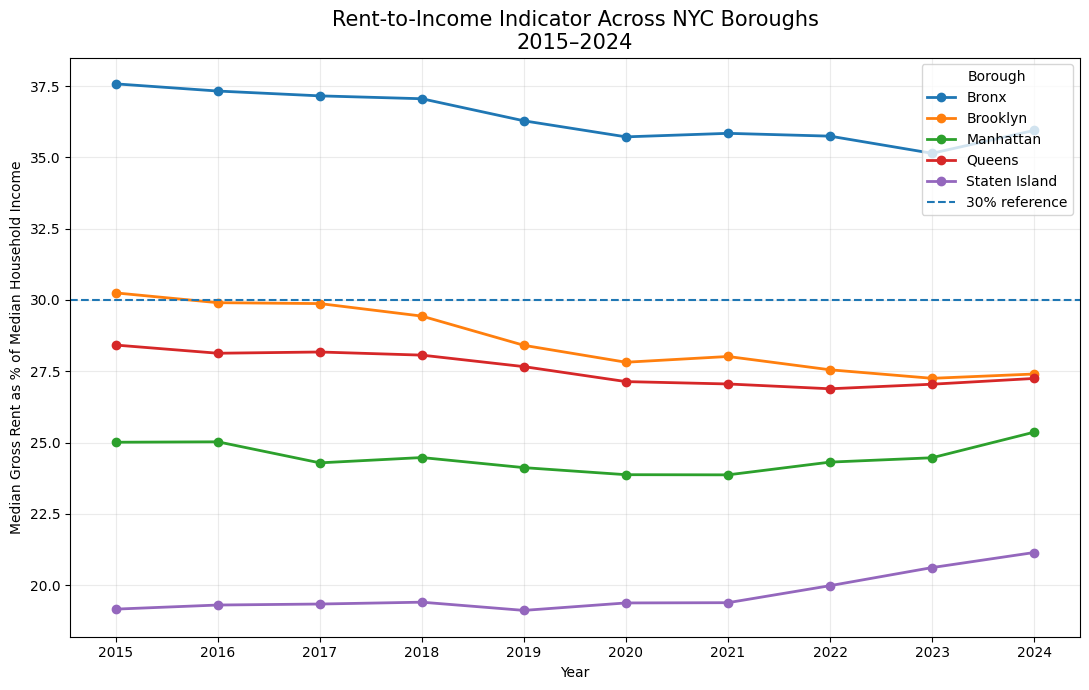

In [87]:
plot_data = nyc_trends.sort_values(["borough", "year"])

plt.figure(figsize=(11, 7))

for borough in plot_data["borough"].unique():
    borough_data = plot_data[plot_data["borough"] == borough]

    plt.plot(
        borough_data["year"],
        borough_data["rent_to_income_pct"],
        marker="o",
        linewidth=2,
        label=borough
    )

plt.axhline(
    y=30,
    linestyle="--",
    linewidth=1.5,
    label="30% reference"
)

plt.title(
    "Rent-to-Income Indicator Across NYC Boroughs\n2015–2024",
    fontsize=15
)

plt.xlabel("Year")
plt.ylabel("Median Gross Rent as % of Median Household Income")

plt.xticks(range(2015, 2025))
plt.legend(title="Borough")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [88]:
summary = change[[
    "borough",
    "income_change_pct",
    "rent_change_pct",
    "affordability_change"
]].copy()

summary.columns = [
    "Borough",
    "Income Change (%)",
    "Rent Change (%)",
    "Rent-to-Income Change (pp)"
]

summary = summary.round(2)

summary.sort_values(
    "Rent-to-Income Change (pp)",
    ascending=False
)

,Borough,Income Change (%),Rent Change (%),Rent-to-Income Change (pp)
4,Staten Island,34.34,48.25,1.98
1,Manhattan,42.62,44.63,0.35
0,Queens,49.23,43.09,-1.17
2,Bronx,41.92,35.75,-1.63
3,Brooklyn,66.52,50.86,-2.84


In [89]:
nyc_trends = nyc_trends.sort_values(["borough", "year"])

nyc_trends["income_yoy_pct"] = (
    nyc_trends.groupby("borough")["median_household_income"]
    .pct_change() * 100
)

nyc_trends["rent_yoy_pct"] = (
    nyc_trends.groupby("borough")["median_gross_rent"]
    .pct_change() * 100
)

nyc_trends[[
    "borough",
    "year",
    "income_yoy_pct",
    "rent_yoy_pct"
]].round(2).head(15)

,borough,year,income_yoy_pct,rent_yoy_pct
2,Bronx,2015,NaN,NaN
7,Bronx,2016,2.92,2.23
10,Bronx,2017,3.66,3.19
17,Bronx,2018,4.08,3.80
22,Bronx,2019,5.26,3.06
27,Bronx,2020,4.51,2.89
30,Bronx,2021,4.37,4.73
35,Bronx,2022,7.57,7.27
40,Bronx,2023,4.25,2.50
45,Bronx,2024,-0.73,1.53


In [90]:
nyc_trends.loc[
    nyc_trends.groupby("borough")["rent_yoy_pct"].idxmax(),
    ["borough", "year", "rent_yoy_pct"]
].round(2)

,borough,year,rent_yoy_pct
35,Bronx,2022,7.27
36,Brooklyn,2022,8.41
37,Manhattan,2022,8.29
38,Queens,2022,7.95
39,Staten Island,2022,10.87


In [91]:
nyc_county_codes = {
    "005": "Bronx",
    "047": "Brooklyn",
    "061": "Manhattan",
    "081": "Queens",
    "085": "Staten Island"
}

def get_tract_data(year, county_code):
    url = f"https://api.census.gov/data/{year}/acs/acs5"

    params = {
        "get": "NAME,B19013_001E,B25064_001E",
        "for": "tract:*",
        "in": f"state:36 county:{county_code}",
        "key": census_key
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    tract_df = pd.DataFrame(data[1:], columns=data[0])

    tract_df = tract_df.rename(columns={
        "NAME": "tract_name",
        "B19013_001E": "median_household_income",
        "B25064_001E": "median_gross_rent"
    })

    tract_df["median_household_income"] = pd.to_numeric(
        tract_df["median_household_income"],
        errors="coerce"
    )

    tract_df["median_gross_rent"] = pd.to_numeric(
        tract_df["median_gross_rent"],
        errors="coerce"
    )

    tract_df["borough"] = nyc_county_codes[county_code]
    tract_df["year"] = year

    return tract_df

In [92]:
manhattan_tracts = get_tract_data(2024, "061")

manhattan_tracts.head()

,tract_name,median_household_income,median_gross_rent,state,county,tract,borough,year
0,Census Tract 1; New York County; New York,-666666666,-666666666,36,061,000100,Manhattan,2024
1,Census Tract 2.01; New York County; New York,37353,1039,36,061,000201,Manhattan,2024
2,Census Tract 2.02; New York County; New York,36688,544,36,061,000202,Manhattan,2024
3,Census Tract 5; New York County; New York,-666666666,-666666666,36,061,000500,Manhattan,2024
4,Census Tract 6; New York County; New York,36893,1002,36,061,000600,Manhattan,2024


In [93]:
print("Number of Manhattan tracts:", len(manhattan_tracts))

manhattan_tracts[[
    "tract_name",
    "median_household_income",
    "median_gross_rent"
]].head(10)

Number of Manhattan tracts: 310


,tract_name,median_household_income,median_gross_rent
0,Census Tract 1; New York County; New York,-666666666,-666666666
1,Census Tract 2.01; New York County; New York,37353,1039
2,Census Tract 2.02; New York County; New York,36688,544
3,Census Tract 5; New York County; New York,-666666666,-666666666
4,Census Tract 6; New York County; New York,36893,1002
5,Census Tract 7; New York County; New York,190388,3501
6,Census Tract 8; New York County; New York,31262,1204
7,Census Tract 9; New York County; New York,250001,3501
8,Census Tract 10.01; New York County; New York,140000,1243
9,Census Tract 10.02; New York County; New York,23796,579


In [94]:
cols = ["median_household_income", "median_gross_rent"]

for col in cols:
    manhattan_tracts.loc[manhattan_tracts[col] < 0, col] = pd.NA

manhattan_tracts[cols].isna().sum()

,0
median_household_income,12
median_gross_rent,10


In [95]:
valid_manhattan = manhattan_tracts.dropna(
    subset=["median_household_income", "median_gross_rent"]
).copy()

print("Total tracts:", len(manhattan_tracts))
print("Usable tracts:", len(valid_manhattan))
print("Removed:", len(manhattan_tracts) - len(valid_manhattan))

Total tracts: 310
Usable tracts: 297
Removed: 13


In [96]:
valid_manhattan["GEOID"] = (
    valid_manhattan["state"]
    + valid_manhattan["county"]
    + valid_manhattan["tract"]
)

valid_manhattan[[
    "GEOID",
    "tract_name",
    "median_household_income",
    "median_gross_rent"
]].head()

,GEOID,tract_name,median_household_income,median_gross_rent
1,36061000201,Census Tract 2.01; New York County; New York,37353.0,1039.0
2,36061000202,Census Tract 2.02; New York County; New York,36688.0,544.0
4,36061000600,Census Tract 6; New York County; New York,36893.0,1002.0
5,36061000700,Census Tract 7; New York County; New York,190388.0,3501.0
6,36061000800,Census Tract 8; New York County; New York,31262.0,1204.0


In [97]:
def get_tract_data(year, county_code):
    url = f"https://api.census.gov/data/{year}/acs/acs5"

    params = {
        "get": "NAME,B19013_001E,B25064_001E",
        "for": "tract:*",
        "in": f"state:36 county:{county_code}",
        "key": census_key
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    tract_df = pd.DataFrame(data[1:], columns=data[0])

    tract_df = tract_df.rename(columns={
        "NAME": "tract_name",
        "B19013_001E": "median_household_income",
        "B25064_001E": "median_gross_rent"
    })

    numeric_cols = [
        "median_household_income",
        "median_gross_rent"
    ]

    for col in numeric_cols:
        tract_df[col] = pd.to_numeric(
            tract_df[col],
            errors="coerce"
        )

        tract_df.loc[tract_df[col] < 0, col] = pd.NA

    tract_df["borough"] = nyc_county_codes[county_code]
    tract_df["year"] = year

    tract_df["GEOID"] = (
        tract_df["state"]
        + tract_df["county"]
        + tract_df["tract"]
    )

    return tract_df

In [98]:
all_tracts = []

for county_code in nyc_county_codes:
    borough_data = get_tract_data(2024, county_code)
    all_tracts.append(borough_data)

nyc_tracts_2024 = pd.concat(
    all_tracts,
    ignore_index=True
)

nyc_tracts_2024.shape

(2327, 9)

In [99]:
tract_check = nyc_tracts_2024.groupby("borough").agg(
    total_tracts=("GEOID", "count"),
    missing_income=("median_household_income", "size")
)

tract_check["missing_income"] = (
    nyc_tracts_2024
    .groupby("borough")["median_household_income"]
    .apply(lambda x: x.isna().sum())
)

tract_check["missing_rent"] = (
    nyc_tracts_2024
    .groupby("borough")["median_gross_rent"]
    .apply(lambda x: x.isna().sum())
)

tract_check

,total_tracts,missing_income,missing_rent
borough,,,
Bronx,361,22,22
Brooklyn,805,36,36
Manhattan,310,12,10
Queens,725,50,64
Staten Island,126,8,10


In [100]:
valid_tracts_2024 = nyc_tracts_2024.dropna(
    subset=["median_household_income", "median_gross_rent"]
).copy()

print("Original tracts:", len(nyc_tracts_2024))
print("Usable tracts:", len(valid_tracts_2024))
print("Removed:", len(nyc_tracts_2024) - len(valid_tracts_2024))

Original tracts: 2327
Usable tracts: 2170
Removed: 157


In [101]:
valid_tracts_2024["annual_gross_rent"] = (
    valid_tracts_2024["median_gross_rent"] * 12
)

valid_tracts_2024["rent_to_income_pct"] = (
    valid_tracts_2024["annual_gross_rent"]
    / valid_tracts_2024["median_household_income"]
    * 100
)

In [102]:
valid_tracts_2024["rent_to_income_pct"].describe()

,rent_to_income_pct
count,2170.000000
mean,29.498008
std,10.396780
min,3.036471
25%,22.783017
50%,27.887147
75%,33.900657
max,117.485613


In [103]:
valid_tracts_2024.sort_values(
    "rent_to_income_pct",
    ascending=False
)[[
    "GEOID",
    "borough",
    "median_household_income",
    "median_gross_rent",
    "rent_to_income_pct"
]].head(10)

,GEOID,borough,median_household_income,median_gross_rent,rent_to_income_pct
287,36005038500,Bronx,13554.0,1327.0,117.485613
1003,36047080800,Brooklyn,13337.0,1096.0,98.612881
270,36005036901,Bronx,16232.0,1231.0,91.005421
1136,36047117000,Brooklyn,27840.0,2107.0,90.818966
213,36005028300,Bronx,13796.0,1013.0,88.112496
33,36005005300,Bronx,20608.0,1410.0,82.104037
171,36005023501,Bronx,19940.0,1364.0,82.086259
82,36005013100,Bronx,19760.0,1273.0,77.307692
180,36005024100,Bronx,22361.0,1440.0,77.277403
145,36005021502,Bronx,20415.0,1305.0,76.708303


In [104]:
valid_tracts_2024["affordability_category"] = pd.cut(
    valid_tracts_2024["rent_to_income_pct"],
    bins=[0, 20, 30, 40, 50, float("inf")],
    labels=[
        "Under 20%",
        "20–30%",
        "30–40%",
        "40–50%",
        "50%+"
    ]
)

valid_tracts_2024["affordability_category"].value_counts().sort_index()

,count
affordability_category,
Under 20%,289
20–30%,1024
30–40%,600
40–50%,162
50%+,95


In [105]:
borough_affordability = pd.crosstab(
    valid_tracts_2024["borough"],
    valid_tracts_2024["affordability_category"],
    normalize="index"
) * 100

borough_affordability = borough_affordability.round(1)

borough_affordability

affordability_category,Under 20%,20–30%,30–40%,40–50%,50%+
borough,,,,,
Bronx,4.2,27.3,34.1,18.4,16.0
Brooklyn,12.8,49.7,28.2,6.4,2.9
Manhattan,19.2,48.1,23.2,7.4,2.0
Queens,11.6,54.9,27.7,4.1,1.7
Staten Island,37.9,42.2,16.4,1.7,1.7


NYC TRACT-LEVEL ANALYSIS — 2024
--------------------------------
Usable census tracts: 2,170
Income/rent correlation: 0.775
R-squared: 0.601
P-value: 0

BOROUGH SUMMARY


,tracts,median_income,median_rent,median_affordability,pct_over_30,pct_over_40,pct_over_50
borough,,,,,,,
Bronx,337,50000.0,1535.0,34.35,68.55,34.42,16.02
Brooklyn,763,79667.0,1842.0,27.78,37.48,9.31,2.88
Queens,657,88167.0,1995.0,27.21,33.49,5.78,1.67
Manhattan,297,121438.0,2518.0,25.66,32.66,9.43,2.02
Staten Island,116,98745.0,1802.5,22.02,19.83,3.45,1.72



15 HIGHEST RENT-TO-INCOME PROXIES


,GEOID,borough,median_household_income,median_gross_rent,rent_to_income_pct
287,36005038500,Bronx,13554.0,1327.0,117.49
1003,36047080800,Brooklyn,13337.0,1096.0,98.61
270,36005036901,Bronx,16232.0,1231.0,91.01
1136,36047117000,Brooklyn,27840.0,2107.0,90.82
213,36005028300,Bronx,13796.0,1013.0,88.11
33,36005005300,Bronx,20608.0,1410.0,82.10
171,36005023501,Bronx,19940.0,1364.0,82.09
82,36005013100,Bronx,19760.0,1273.0,77.31
180,36005024100,Bronx,22361.0,1440.0,77.28
145,36005021502,Bronx,20415.0,1305.0,76.71


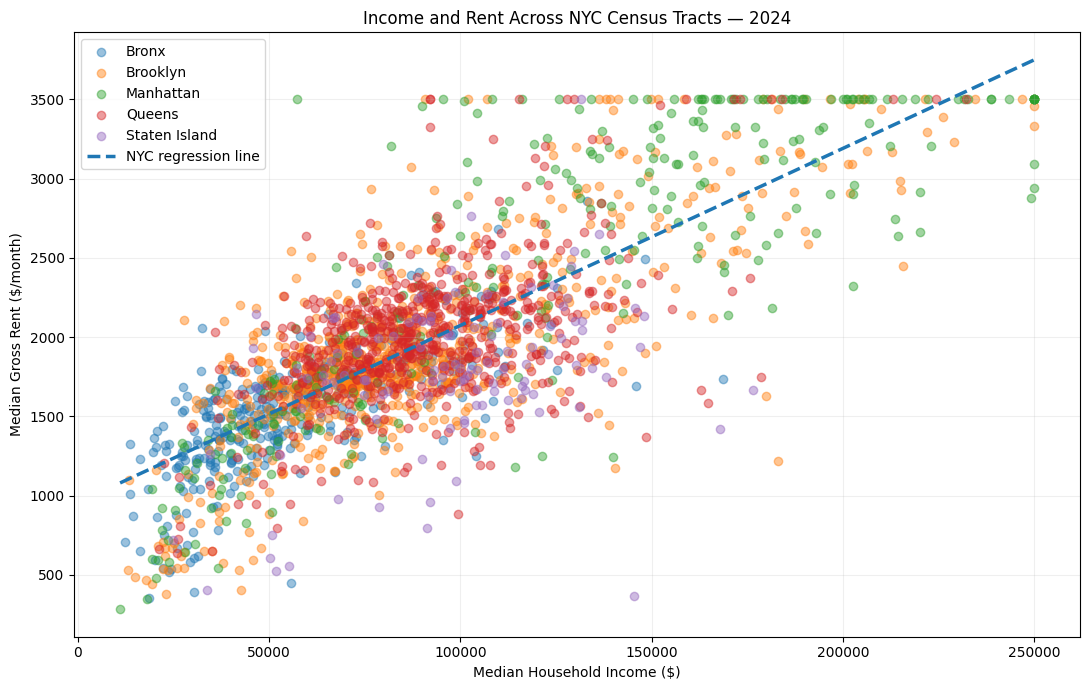

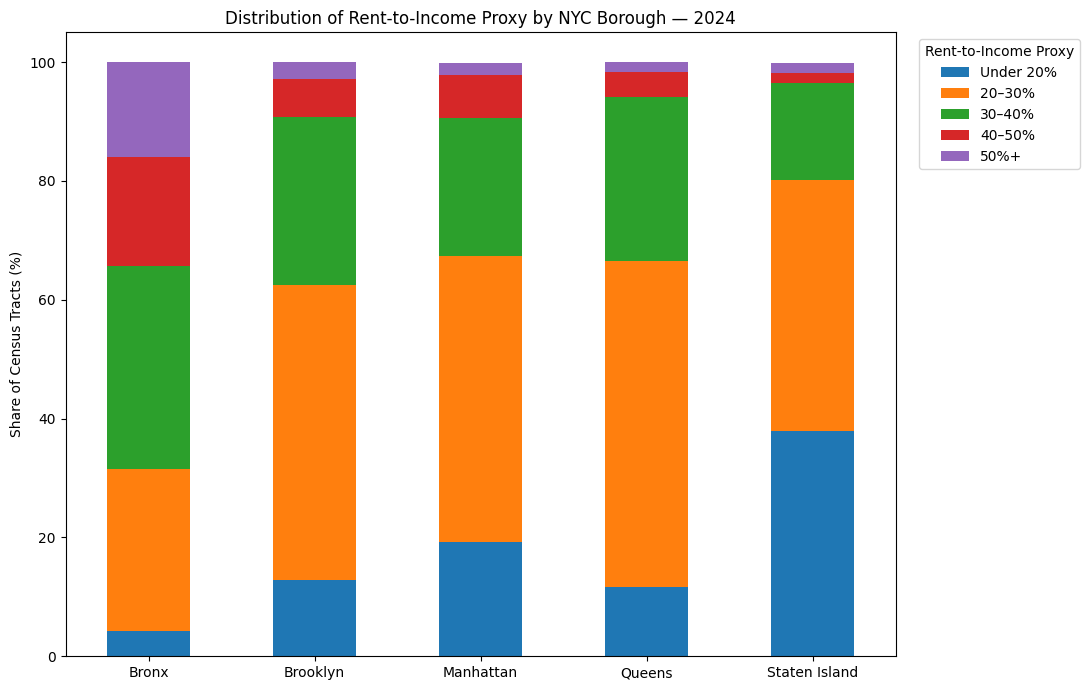

In [106]:
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

analysis = valid_tracts_2024.copy()

# -----------------------------
# 1. Income vs. rent statistics
# -----------------------------

corr, p_value = pearsonr(
    analysis["median_household_income"],
    analysis["median_gross_rent"]
)

X = analysis[["median_household_income"]]
y = analysis["median_gross_rent"]

model = LinearRegression()
model.fit(X, y)

analysis["predicted_rent"] = model.predict(X)

r_squared = model.score(X, y)

print("NYC TRACT-LEVEL ANALYSIS — 2024")
print("--------------------------------")
print(f"Usable census tracts: {len(analysis):,}")
print(f"Income/rent correlation: {corr:.3f}")
print(f"R-squared: {r_squared:.3f}")
print(f"P-value: {p_value:.5g}")


# -----------------------------
# 2. Borough summary
# -----------------------------

borough_summary = (
    analysis.groupby("borough")
    .agg(
        tracts=("GEOID", "count"),
        median_income=("median_household_income", "median"),
        median_rent=("median_gross_rent", "median"),
        median_affordability=("rent_to_income_pct", "median"),
        pct_over_30=("rent_to_income_pct", lambda x: (x >= 30).mean() * 100),
        pct_over_40=("rent_to_income_pct", lambda x: (x >= 40).mean() * 100),
        pct_over_50=("rent_to_income_pct", lambda x: (x >= 50).mean() * 100)
    )
    .round(2)
    .sort_values("median_affordability", ascending=False)
)

print("\nBOROUGH SUMMARY")
display(borough_summary)


# -----------------------------
# 3. Highest affordability ratios
# -----------------------------

highest_burden = (
    analysis[
        [
            "GEOID",
            "borough",
            "median_household_income",
            "median_gross_rent",
            "rent_to_income_pct"
        ]
    ]
    .sort_values("rent_to_income_pct", ascending=False)
    .head(15)
    .round(2)
)

print("\n15 HIGHEST RENT-TO-INCOME PROXIES")
display(highest_burden)


# -----------------------------
# 4. Income vs. rent visualization
# -----------------------------

plt.figure(figsize=(11, 7))

for borough in sorted(analysis["borough"].unique()):
    temp = analysis[analysis["borough"] == borough]

    plt.scatter(
        temp["median_household_income"],
        temp["median_gross_rent"],
        alpha=0.45,
        label=borough
    )

income_range = np.linspace(
    analysis["median_household_income"].min(),
    analysis["median_household_income"].max(),
    200
)

predicted = model.predict(
    pd.DataFrame(
        {"median_household_income": income_range}
    )
)

plt.plot(
    income_range,
    predicted,
    linewidth=2.5,
    linestyle="--",
    label="NYC regression line"
)

plt.xlabel("Median Household Income ($)")
plt.ylabel("Median Gross Rent ($/month)")
plt.title("Income and Rent Across NYC Census Tracts — 2024")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# -----------------------------
# 5. Affordability distribution
# -----------------------------

borough_affordability.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7)
)

plt.title("Distribution of Rent-to-Income Proxy by NYC Borough — 2024")
plt.xlabel("")
plt.ylabel("Share of Census Tracts (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Rent-to-Income Proxy",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

NYC MAP DATA
----------------------------
Total NYC tract shapes: 2,327
Tracts with affordability data: 2,170


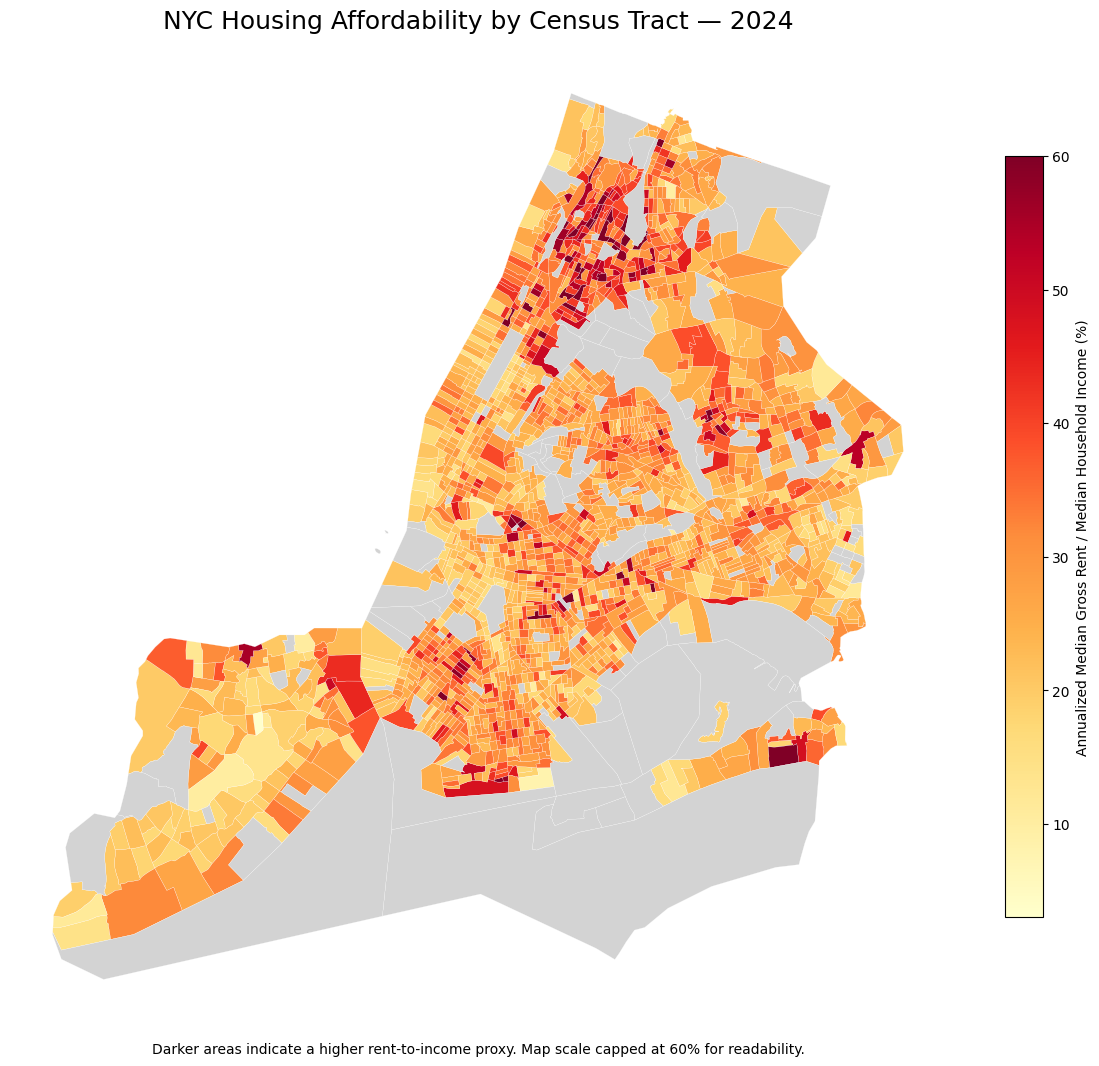

,usable_tracts,median_income,median_rent,median_rent_to_income
borough,,,,
Bronx,337,50000.0,1535.0,34.35
Brooklyn,763,79667.0,1842.0,27.78
Queens,657,88167.0,1995.0,27.21
Manhattan,297,121438.0,2518.0,25.66
Staten Island,116,98745.0,1802.5,22.02


In [107]:
# ============================================================
# NYC AFFORDABILITY CHOROPLETH MAP
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt

# NYC census tract boundaries from Census TIGER/Line
tract_url = (
    "https://www2.census.gov/geo/tiger/TIGER2024/TRACT/"
    "tl_2024_36_tract.zip"
)

ny_tract_shapes = gpd.read_file(tract_url)

# Keep only NYC counties
nyc_counties = ["005", "047", "061", "081", "085"]

nyc_shapes = ny_tract_shapes[
    ny_tract_shapes["COUNTYFP"].isin(nyc_counties)
].copy()

# Make sure GEOID is stored the same way in both datasets
nyc_shapes["GEOID"] = nyc_shapes["GEOID"].astype(str)
analysis["GEOID"] = analysis["GEOID"].astype(str)

# Merge Census statistics with geographic boundaries
nyc_map = nyc_shapes.merge(
    analysis[
        [
            "GEOID",
            "borough",
            "median_household_income",
            "median_gross_rent",
            "rent_to_income_pct"
        ]
    ],
    on="GEOID",
    how="left"
)

print("NYC MAP DATA")
print("----------------------------")
print(f"Total NYC tract shapes: {len(nyc_map):,}")
print(
    f"Tracts with affordability data: "
    f"{nyc_map['rent_to_income_pct'].notna().sum():,}"
)

# Cap the map scale at 60% so a few extreme tracts
# do not distort the colors for the rest of NYC
nyc_map["map_affordability"] = (
    nyc_map["rent_to_income_pct"].clip(upper=60)
)

# Draw map
fig, ax = plt.subplots(figsize=(12, 12))

nyc_map.plot(
    column="map_affordability",
    cmap="YlOrRd",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No usable ACS estimate"
    },
    legend_kwds={
        "label": "Annualized Median Gross Rent / Median Household Income (%)",
        "shrink": 0.65
    },
    ax=ax
)

ax.set_title(
    "NYC Housing Affordability by Census Tract — 2024",
    fontsize=18,
    pad=15
)

ax.text(
    0.5,
    -0.03,
    "Darker areas indicate a higher rent-to-income proxy. "
    "Map scale capped at 60% for readability.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# BOROUGH MEDIANS FOR MAP CONTEXT
# ============================================================

map_summary = (
    analysis.groupby("borough")
    .agg(
        usable_tracts=("GEOID", "count"),
        median_income=("median_household_income", "median"),
        median_rent=("median_gross_rent", "median"),
        median_rent_to_income=("rent_to_income_pct", "median")
    )
    .round(2)
    .sort_values("median_rent_to_income", ascending=False)
)

display(map_summary)

In [109]:
# FINAL EXPORT

import os
import pandas as pd

os.makedirs("outputs", exist_ok=True)

# Combine yearly data into one DataFrame
all_years_df = pd.concat(all_years, ignore_index=True)

# Save files
all_years_df.to_csv(
    "outputs/nyc_borough_affordability_2015_2024.csv",
    index=False
)

valid_tracts_2024.to_csv(
    "outputs/nyc_tract_affordability_2024.csv",
    index=False
)

borough_summary.to_csv(
    "outputs/borough_summary_2024.csv"
)

highest_burden.to_csv(
    "outputs/highest_burden_tracts_2024.csv",
    index=False
)

# Save map
fig.savefig(
    "outputs/nyc_affordability_map_2024.png",
    dpi=300,
    bbox_inches="tight"
)

print("FINAL PROJECT FILES SAVED")
print("-------------------------")

for file in os.listdir("outputs"):
    print(file)

FINAL PROJECT FILES SAVED
-------------------------
nyc_affordability_map_2024.png
nyc_tract_affordability_2024.csv
nyc_borough_affordability_2015_2024.csv
highest_burden_tracts_2024.csv
borough_summary_2024.csv
